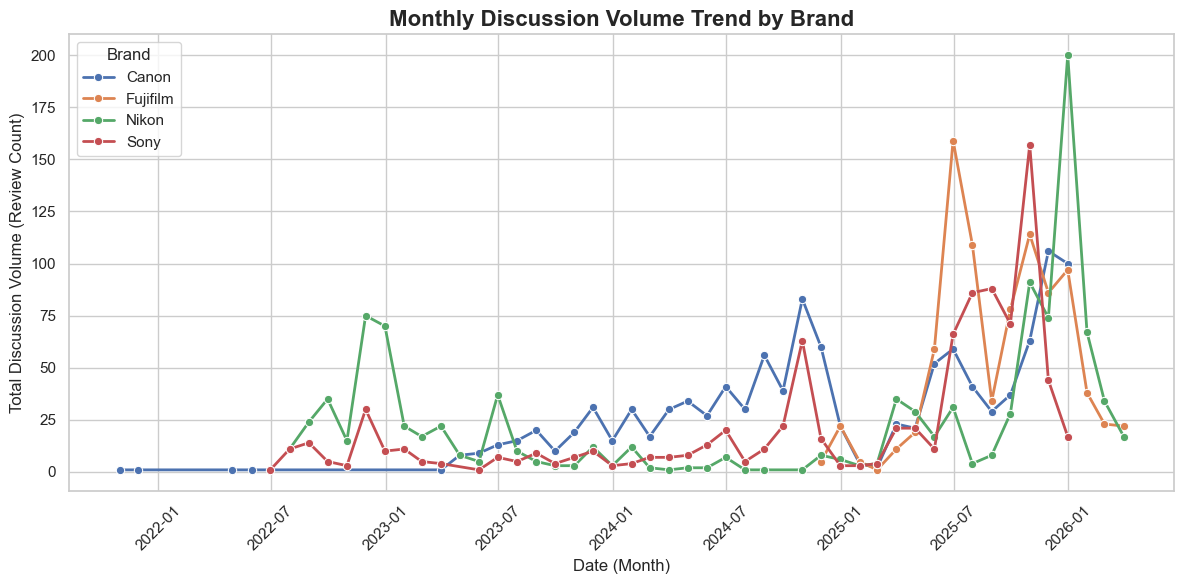

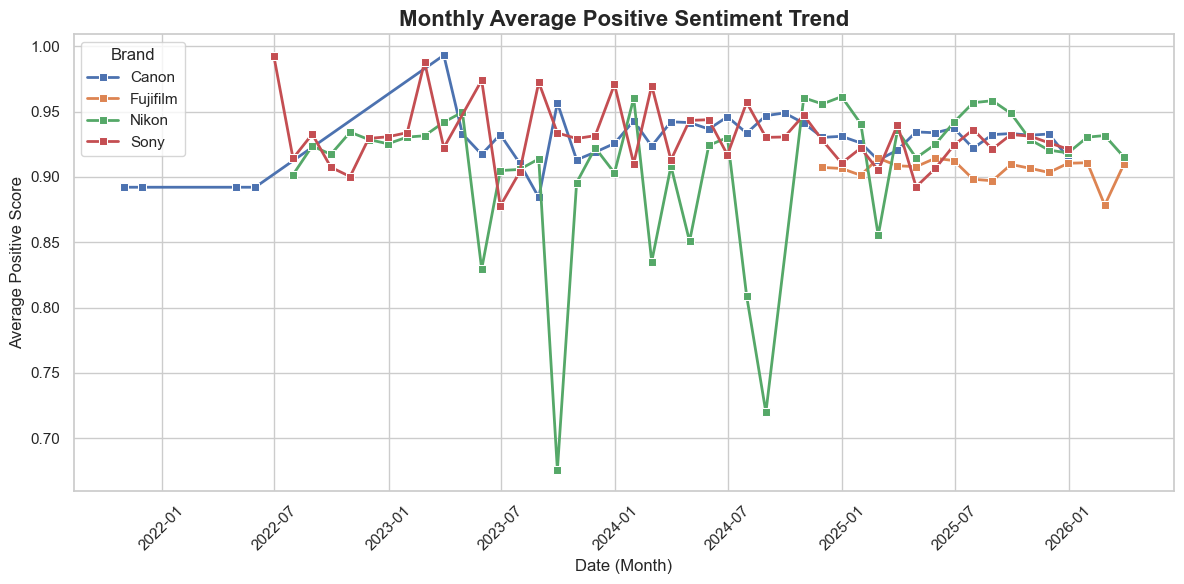

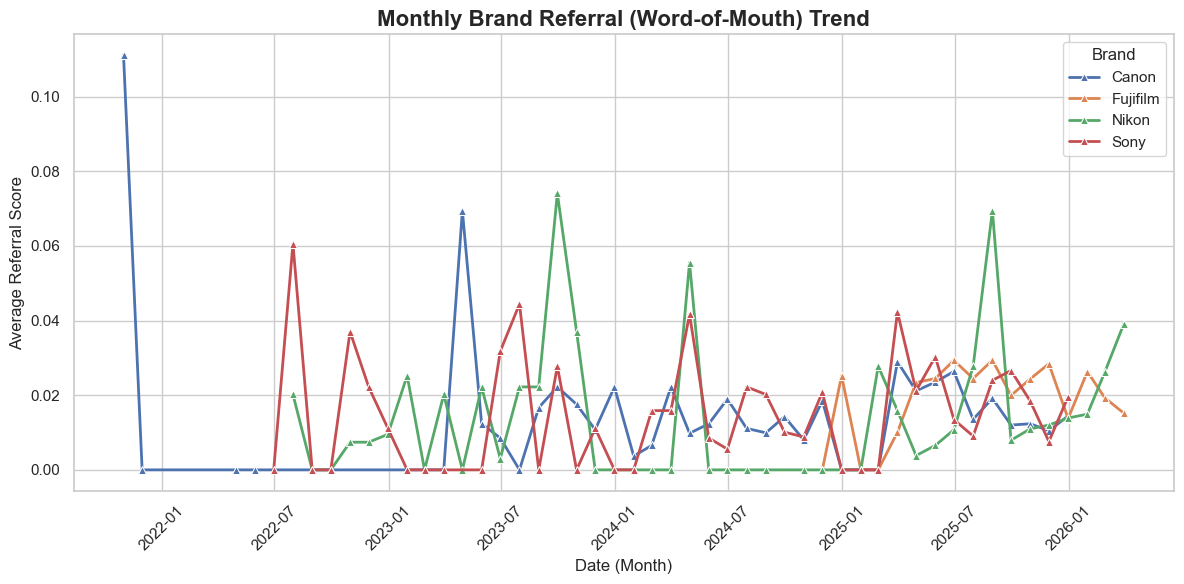

🎉 搞定！三张时序图已生成，时序数据已成功导出为: final_timeseries_data.csv


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # 保持输出界面干净

# 1. 读取数据 (请确保文件名与你电脑中的一致)
# 如果是 excel 文件，请把 read_csv 改成 read_excel
df = pd.read_excel('camera_reviews_sentiment_analysis.xlsx')

# 2. 数据预处理
# 映射英文品牌名，防止画图时中文字体变成小方块乱码
brand_map = {'佳能': 'Canon', '索尼': 'Sony', '尼康': 'Nikon', '富士': 'Fujifilm'}
df['Brand_EN'] = df['品牌'].map(lambda x: brand_map.get(x, x))

# 将时间列转换为标准日期格式，并剔除无效时间
df['时间'] = pd.to_datetime(df['时间'], errors='coerce')
df = df.dropna(subset=['时间'])

# 3. 核心：按【品牌】和【月份】聚合数据
# freq='M' 代表按月汇总。如果想按周，改成 freq='W'
trend_data = df.groupby(['Brand_EN', pd.Grouper(key='时间', freq='ME')]).agg(
    volume=('评论内容', 'count'),          # 图1用的 Y 轴：评论总数
    avg_pos=('positive_score', 'mean'),  # 图2用的 Y 轴：平均正面得分
    avg_ref=('referral_score', 'mean')   # 图3用的 Y 轴：平均推荐得分
).reset_index()

# ------------------- 开始画图 -------------------
# 设置全局画图风格
sns.set_theme(style="whitegrid")

# 【图 1】各品牌随时间的热度趋势
plt.figure(figsize=(12, 6))
sns.lineplot(data=trend_data, x='时间', y='volume', hue='Brand_EN', marker='o', linewidth=2)
plt.title('Monthly Discussion Volume Trend by Brand', fontsize=16, fontweight='bold')
plt.xlabel('Date (Month)', fontsize=12)
plt.ylabel('Total Discussion Volume (Review Count)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Brand')
plt.tight_layout()
plt.savefig('Plot_1_Volume_Trend.png', dpi=300)
plt.show() # 显示图片

# 【图 2】各品牌随时间的正面口碑变化
plt.figure(figsize=(12, 6))
sns.lineplot(data=trend_data, x='时间', y='avg_pos', hue='Brand_EN', marker='s', linewidth=2)
plt.title('Monthly Average Positive Sentiment Trend', fontsize=16, fontweight='bold')
plt.xlabel('Date (Month)', fontsize=12)
plt.ylabel('Average Positive Score', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Brand')
plt.tight_layout()
plt.savefig('Plot_2_Positive_Sentiment.png', dpi=300)
plt.show()

# 【图 3】各品牌随时间的“推荐/种草”得分趋势
plt.figure(figsize=(12, 6))
sns.lineplot(data=trend_data, x='时间', y='avg_ref', hue='Brand_EN', marker='^', linewidth=2)
plt.title('Monthly Brand Referral (Word-of-Mouth) Trend', fontsize=16, fontweight='bold')
plt.xlabel('Date (Month)', fontsize=12)
plt.ylabel('Average Referral Score', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Brand')
plt.tight_layout()
plt.savefig('Plot_3_Referral_Trend.png', dpi=300)
plt.show()

# ------------------- 导出数据 -------------------
# 4. 将用于画图的最终时序数据保存为 CSV，方便你做表格或放入报告
output_filename = 'final_timeseries_data.csv'
trend_data.to_csv(output_filename, index=False)
print(f"🎉 搞定！三张时序图已生成，时序数据已成功导出为: {output_filename}")